<a href="https://colab.research.google.com/github/vinnijmrtl/Bismillah/blob/main/ETS%20Pembelajran%20Mesin.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

libraries

In [ ]:
# Import Data Science Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Tensorflow Libraries
from tensorflow import keras
from tensorflow.keras import layers,models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import Callback, EarlyStopping,ModelCheckpoint, ReduceLROnPlateau
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import Model

# System libraries
from pathlib import Path
import os.path
import random
from collections import Counter

# Visualization Libraries
import matplotlib.cm as cm
import cv2
import seaborn as sns
from cycler import cycler
import textwrap

sns.set_style('darkgrid')

# Metrics
from sklearn.metrics import classification_report, confusion_matrix
import itertools

dataset

In [ ]:
!kaggle datasets download vencerlanz09/alzheimers-mri-brain-scan-images-augmented

Dataset URL: https://www.kaggle.com/datasets/vencerlanz09/alzheimers-mri-brain-scan-images-augmented
License(s): Attribution 4.0 International (CC BY 4.0)
100% 167M/167M [00:05<00:00, 29.7MB/s]



In [ ]:
import os

print(os.listdir())

['.config', 'alzheimers-mri-brain-scan-images-augmented.zip', 'sample_data']


unzip data set

In [ ]:
!unzip -q alzheimers-mri-brain-scan-images-augmented.zip

In [ ]:
print(os.listdir())

['.config', 'alzheimers-mri-brain-scan-images-augmented.zip', 'test_images', 'train_images', 'sample_data']


Path Dataset

In [ ]:
train_dir = "/content/train_images"
test_dir = "/content/test_images"

ImageDataGenerator

In [10]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.2
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

visualisasi data

In [11]:
import os
import pandas as pd

train_dir = "/content/train_images"

filepaths = []
labels = []

for label in os.listdir(train_dir):
    label_path = os.path.join(train_dir, label)

    if os.path.isdir(label_path):
        for file in os.listdir(label_path):
            filepaths.append(os.path.join(label_path, file))
            labels.append(label)

train_df = pd.DataFrame({
    "Filepath": filepaths,
    "Label": labels
})

train_df.head()

,Filepath,Label
0,/content/train_images/mild_dementia/00003886.jpg,mild_dementia
1,/content/train_images/mild_dementia/00006362.jpg,mild_dementia
2,/content/train_images/mild_dementia/00000566.jpg,mild_dementia
3,/content/train_images/mild_dementia/00007431.jpg,mild_dementia
4,/content/train_images/mild_dementia/00001921.jpg,mild_dementia


In [12]:
print(train_df.head())

                                           Filepath          Label
0  /content/train_images/mild_dementia/00003886.jpg  mild_dementia
1  /content/train_images/mild_dementia/00006362.jpg  mild_dementia
2  /content/train_images/mild_dementia/00000566.jpg  mild_dementia
3  /content/train_images/mild_dementia/00007431.jpg  mild_dementia
4  /content/train_images/mild_dementia/00001921.jpg  mild_dementia


{'mild_dementia': 10217, 'moderated_dementia': 9678, 'non_demented': 11560, 'very_mild_demented': 10792}


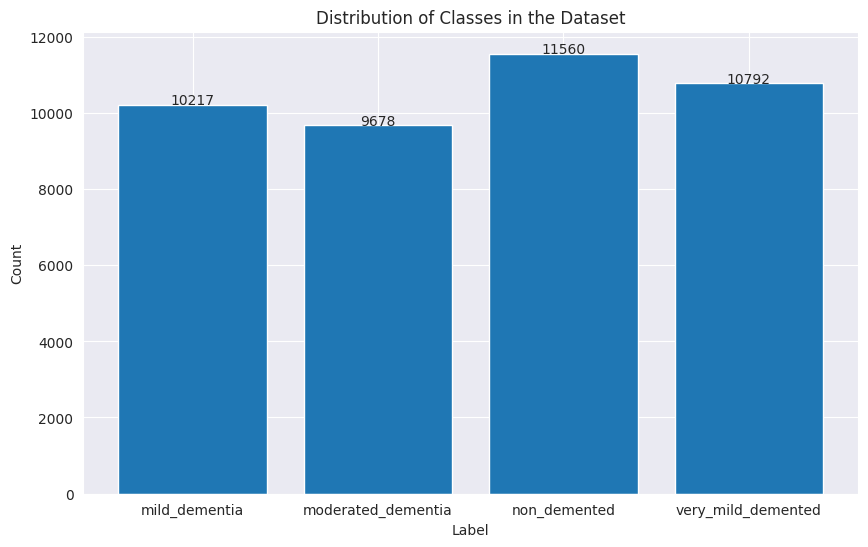

In [14]:
import os
import matplotlib.pyplot as plt

# Path ke folder training
train_dir = "/content/train_images"

# Ambil jumlah gambar per kelas
class_counts = {}

for class_name in os.listdir(train_dir):
    class_path = os.path.join(train_dir, class_name)

    if os.path.isdir(class_path):
        num_images = len(os.listdir(class_path))
        class_counts[class_name] = num_images

# Tampilkan hasil
print(class_counts)

# Plot bar chart
plt.figure(figsize=(10,6))

plt.bar(
    class_counts.keys(),
    class_counts.values()
)

plt.title("Distribution of Classes in the Dataset")
plt.xlabel("Label")
plt.ylabel("Count")

# tampilkan angka di atas bar
for i, v in enumerate(class_counts.values()):
    plt.text(i, v, str(v), ha="center")

plt.show()

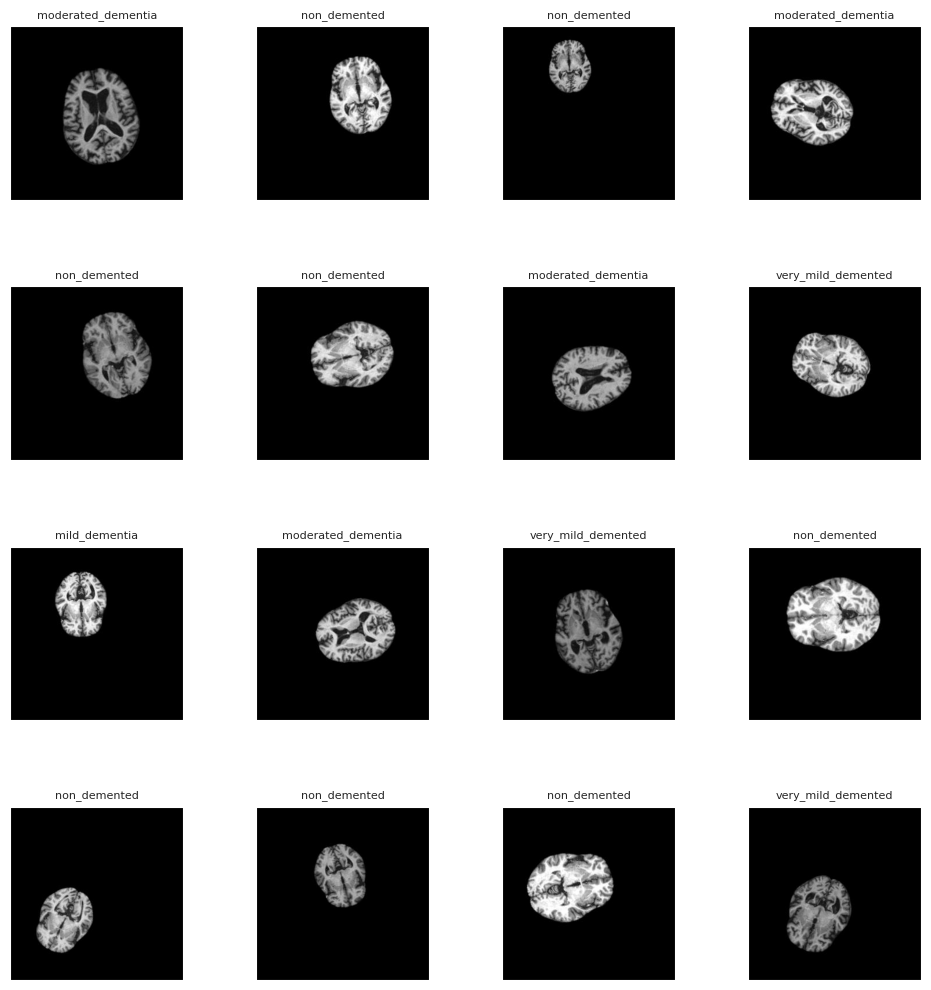

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import textwrap

# Set style
plt.rcParams['axes.titlesize'] = 'small'
plt.rcParams['figure.facecolor'] = 'white'

# Ambil 16 index random
random_index = np.random.randint(
    0,
    len(train_df),
    16
)

fig, axes = plt.subplots(
    nrows=4,
    ncols=4,
    figsize=(10, 10),
    subplot_kw={'xticks': [], 'yticks': []}
)

for i, ax in enumerate(axes.flat):

    ax.imshow(
        plt.imread(
            train_df.Filepath[random_index[i]]
        )
    )

    title = train_df.Label[random_index[i]]

    ax.set_title(
        "\n".join(
            textwrap.wrap(title, 20)
        ),
        fontsize=8
    )

plt.tight_layout()
plt.subplots_adjust(hspace=0.5)

plt.show()

In [16]:
def compute_ela_cv(path, quality):
    temp_filename = 'temp_file_name.jpeg'
    SCALE = 15
    orig_img = cv2.imread(path)
    orig_img = cv2.cvtColor(orig_img, cv2.COLOR_BGR2RGB)

    cv2.imwrite(temp_filename, orig_img, [cv2.IMWRITE_JPEG_QUALITY, quality])

    # read compressed image
    compressed_img = cv2.imread(temp_filename)

    # get absolute difference between img1 and img2 and multiply by scale
    diff = SCALE * cv2.absdiff(orig_img, compressed_img)
    return diff


def convert_to_ela_image(path, quality):
    temp_filename = 'temp_file_name.jpeg'
    ela_filename = 'temp_ela.png'
    image = Image.open(path).convert('RGB')
    image.save(temp_filename, 'JPEG', quality = quality)
    temp_image = Image.open(temp_filename)

    ela_image = ImageChops.difference(image, temp_image)

    extrema = ela_image.getextrema()
    max_diff = max([ex[1] for ex in extrema])
    if max_diff == 0:
        max_diff = 1

    scale = 255.0 / max_diff
    ela_image = ImageEnhance.Brightness(ela_image).enhance(scale)

    return ela_image


def random_sample(path, extension=None):
    if extension:
        items = Path(path).glob(f'*.{extension}')
    else:
        items = Path(path).glob(f'*')

    items = list(items)

    p = random.choice(items)
    return p.as_posix()

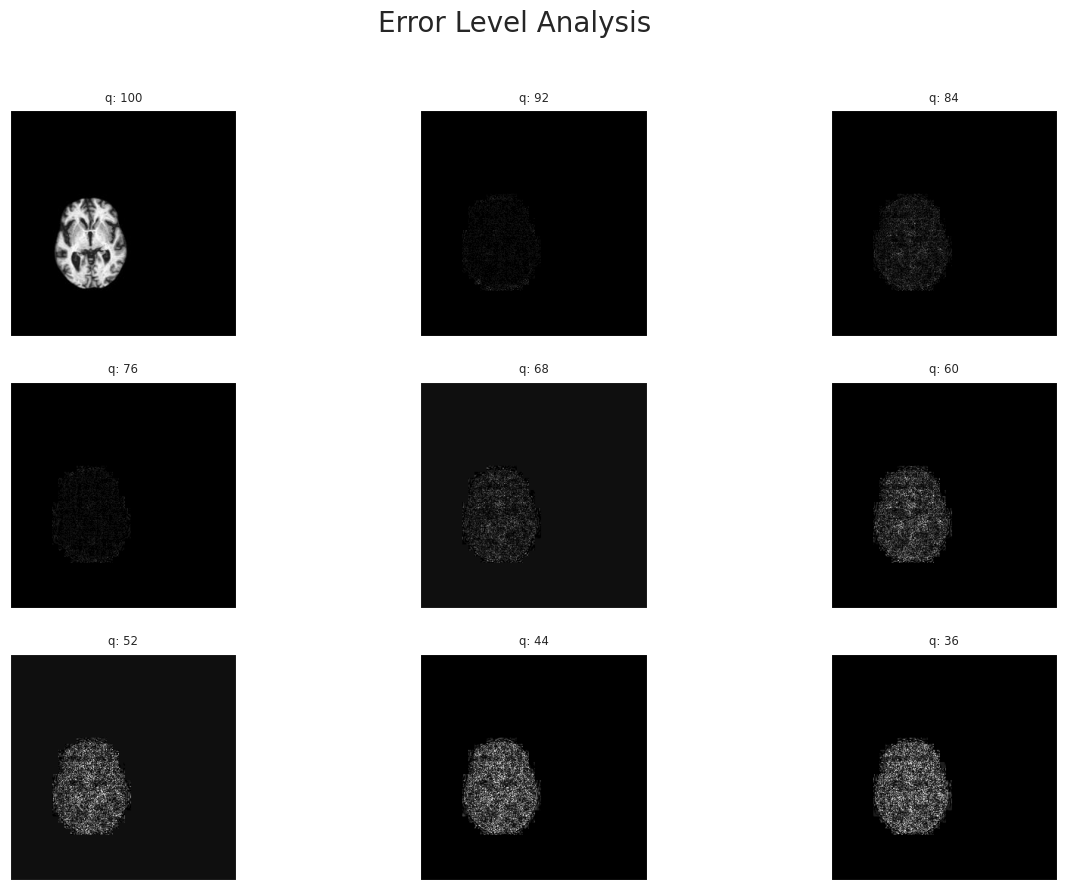

In [17]:
# View random sample from the dataset

p = random_sample('/content/train_images/mild_dementia')

orig = cv2.imread(p)
orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB) / 255.0

init_val = 100
columns = 3
rows = 3

fig = plt.figure(figsize=(15, 10))
fig.suptitle('Error Level Analysis', fontsize=20)

for i in range(1, columns*rows + 1):

    quality = init_val - (i-1) * 8

    img = compute_ela_cv(
        path=p,
        quality=quality
    )

    if i == 1:
        img = orig.copy()

    ax = fig.add_subplot(rows, columns, i)

    ax.title.set_text(f'q: {quality}')

    plt.imshow(img)

    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

In [18]:
PROCESSING_MODULE = tf.keras.applications.efficientnet_v2.preprocess_input
train_generator = ImageDataGenerator(
    preprocessing_function=PROCESSING_MODULE,
    validation_split=0.2
)

test_generator = ImageDataGenerator(
    preprocessing_function=PROCESSING_MODULE
)

In [19]:
import os
import pandas as pd

test_dir = "/content/test_images"   # SESUAIKAN PATH

filepaths = []
labels = []

for label in os.listdir(test_dir):

    label_path = os.path.join(test_dir, label);

    if os.path.isdir(label_path):

        for file in os.listdir(label_path):

            filepaths.append(
                os.path.join(label_path, file)
            )

            labels.append(label)

test_df = pd.DataFrame({
    "Filepath": filepaths,
    "Label": labels
})

print("Jumlah data test:", len(test_df))
print(test_df["Label"].unique())

Jumlah data test: 1279
['VeryMildDemented' 'NonDemented' 'ModerateDemented' 'MildDemented']


In [20]:
TARGET_SIZE = (224, 224)
BATCH_SIZE = 32

train_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col="Filepath",
    y_col="Label",
    target_size=TARGET_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    subset="training"
)

val_images = train_generator.flow_from_dataframe(
    dataframe=train_df,
    x_col="Filepath",
    y_col="Label",
    target_size=TARGET_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=42,
    subset="validation"
)

test_images = test_generator.flow_from_dataframe(
    dataframe=test_df,
    x_col="Filepath",
    y_col="Label",
    target_size=TARGET_SIZE,
    color_mode="rgb",
    class_mode="categorical",
    batch_size=BATCH_SIZE,
    shuffle=False
)

Found 33798 validated image filenames belonging to 4 classes.
Found 8449 validated image filenames belonging to 4 classes.
Found 1279 validated image filenames belonging to 4 classes.


In [21]:
pretrained_model = tf.keras.applications.efficientnet_v2.EfficientNetV2B0(
    input_shape=(224, 224, 3),
    include_top=False,
    weights='imagenet',
    pooling='max'
)

pretrained_model.trainable = False

24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [22]:
checkpoint_path = "mld_classification_model_checkpoint.weights.h5"

checkpoint_callback = ModelCheckpoint(
    checkpoint_path,
    save_weights_only=True,
    monitor="val_accuracy",
    save_best_only=True
)

early_stopping = EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.2,
    patience=3,
    min_lr=1e-6
)

In [28]:
import tensorflow as tf

def f1_score(y_true, y_pred):
    y_pred = tf.round(y_pred)
    y_true = tf.round(y_true)

    tp = tf.reduce_sum(y_true * y_pred)
    fp = tf.reduce_sum((1 - y_true) * y_pred)
    fn = tf.reduce_sum(y_true * (1 - y_pred))

    precision = tp / (tp + fp + tf.keras.backend.epsilon())
    recall = tp / (tp + fn + tf.keras.backend.epsilon())

    f1 = 2 * precision * recall / (precision + recall + tf.keras.backend.epsilon())

    return f1

In [29]:
import tensorflow as tf
import datetime

def create_tensorboard_callback(dir_name, experiment_name):
    log_dir = dir_name + "/" + experiment_name + "/" + datetime.datetime.now().strftime("%Y%m%d-%H%M%S")

    tensorboard_callback = tf.keras.callbacks.TensorBoard(
        log_dir=log_dir
    )

    print(f"Saving TensorBoard log files to: {log_dir}")

    return tensorboard_callback

In [ ]:
# Existing model structure
inputs = pretrained_model.input
x = Dense(128, activation='relu')(pretrained_model.output)
x = Dropout(0.45)(x)
# x = Dense(256, activation='relu')(x)
# x = Dropout(0.45)(x)
outputs = Dense(4, activation='softmax')(x)

model = Model(inputs=inputs, outputs=outputs)

# Compile with custom F1-Score
model.compile(
    optimizer=Adam(0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy', f1_score]
)

history = model.fit(
    train_images,
    steps_per_epoch=len(train_images),
    validation_data=val_images,
    validation_steps=len(val_images),
    epochs=100,
    callbacks=[
        early_stopping,
        create_tensorboard_callback("training_logs", "mld_classification"),
        checkpoint_callback,
        reduce_lr
    ]
)

Saving TensorBoard log files to: training_logs/mld_classification/20260424-094122
Epoch 1/100
1057/1057 ━━━━━━━━━━━━━━━━━━━━ 2570s 2s/step - accuracy: 0.5906 - f1_score: 0.5468 - loss: 0.9974 - val_accuracy: 0.0052 - val_f1_score: 0.0000e+00 - val_loss: 2.5868 - learning_rate: 1.0000e-04
Epoch 2/100
1057/1057 ━━━━━━━━━━━━━━━━━━━━ 2467s 2s/step - accuracy: 0.6503 - f1_score: 0.6118 - loss: 0.7554 - val_accuracy: 0.0155 - val_f1_score: 3.0522e-04 - val_loss: 2.4070 - learning_rate: 1.0000e-04
Epoch 3/100
1057/1057 ━━━━━━━━━━━━━━━━━━━━ 2497s 2s/step - accuracy: 0.6743 - f1_score: 0.6388 - loss: 0.7143 - val_accuracy: 0.0181 - val_f1_score: 3.2130e-04 - val_loss: 2.2794 - learning_rate: 1.0000e-04
Epoch 4/100
1057/1057 ━━━━━━━━━━━━━━━━━━━━ 2492s 2s/step - accuracy: 0.6882 - f1_score: 0.6570 - loss: 0.6879 - val_accuracy: 0.0434 - val_f1_score: 0.0013 - val_loss: 2.0933 - learning_rate: 2.0000e-05
Epoch 5/100
1057/1057 ━━━━━━━━━━━━━━━━━━━━ 2520s 2s/step - accuracy: 0.6894 - f1_score: 0.6629